### OpenCV(Open Source Computer Vision) 개요
- Computer Vision : 사람의 시각적인 부분을 기계로 구현하는 것을 목적으로 하는 딥러닝 분야
- OpenCV : 이미지, 동영상 등의 처리를 지원하는 라이브러리
    - C++로 제작되어 있고, Java, JS, Android, Python 등 다양한 언어에서 활용가능
    - 특히 파이썬에서 사용할 경우 Numpy, Matplotlib 등의 라이브러리와 바로 연동 가능
    

- https://opencv.org/ : OpenCV 공식 사이트
- https://github.com/opencv/opencv : OpenCV github 사이트

In [3]:
# OpenCV 설치
!pip install opencv-python

                                              0.0/38.1 MB ? eta -:--:--
                                              0.0/38.1 MB ? eta -:--:--
                                              0.2/38.1 MB 2.9 MB/s eta 0:00:13
                                              0.2/38.1 MB 3.0 MB/s eta 0:00:13
                                              0.3/38.1 MB 1.9 MB/s eta 0:00:20
                                              0.5/38.1 MB 2.4 MB/s eta 0:00:16
                                              0.5/38.1 MB 2.2 MB/s eta 0:00:18
                                              0.7/38.1 MB 2.5 MB/s eta 0:00:16
     -                                        1.0/38.1 MB 3.0 MB/s eta 0:00:13
     -                                        1.2/38.1 MB 3.1 MB/s eta 0:00:12
     -                                        1.5/38.1 MB 3.6 MB/s eta 0:00:11
     -                                        1.7/38.1 MB 3.6 MB/s eta 0:00:11
     -                                        1.7/38.1 MB 3.6 MB/s

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 # OpenCV 임포트

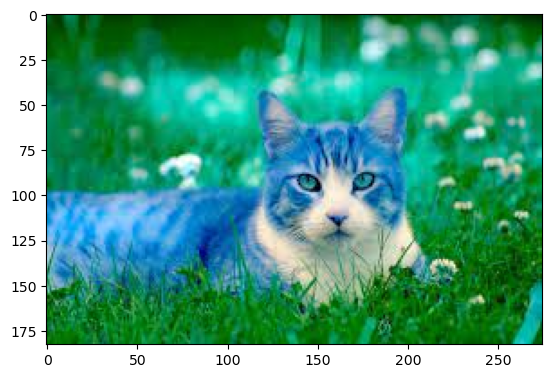

In [5]:
cat = cv2.imread('image/image_cat.JPG')
plt.imshow(cat);

In [6]:
cat

array([[[  0,  97,  35],
        [  0,  90,  29],
        [  0,  78,  19],
        ...,
        [  4,  35,   0],
        [  6,  34,   0],
        [  6,  34,   0]],

       [[  0,  98,  36],
        [  0,  91,  30],
        [  0,  79,  20],
        ...,
        [  3,  37,   0],
        [  4,  37,   0],
        [  4,  37,   0]],

       [[  2,  99,  35],
        [  1,  92,  29],
        [  3,  81,  20],
        ...,
        [  1,  43,   2],
        [  3,  43,   2],
        [  3,  43,   2]],

       ...,

       [[ 11, 113,  12],
        [ 23, 125,  23],
        [ 11, 116,  11],
        ...,
        [  0,  86,   8],
        [  4,  95,   9],
        [ 14, 105,  20]],

       [[  2, 105,   0],
        [ 11, 114,   9],
        [  0, 104,   0],
        ...,
        [  0,  87,   8],
        [  1,  92,   7],
        [  6,  94,  11]],

       [[  2, 103,   0],
        [  4, 109,   0],
        [  0,  97,   0],
        ...,
        [  4,  90,  12],
        [  0,  88,   5],
        [  0,  83,   3]]

### OpenCV의 색상 체계
- 일반적인 이미지를 matplotlib으로 출력 시 RGB 색상 체계를 사용
- OpenCV는 BGR 색상 체계를 사용 (RBG의 순서가 바뀜!)
- 그래서 RGB이미지를 cv2로 불러와서 matplotlib으로 출력하면 Red계열 색상이 Blue계열 색상으로 변경되어 출력됨
- 초창기에는 알파벳 순서대로 BGR로 표현했고, 이후에 색상 주파수에 낮은 순서대로 바뀌어서 대중적으로 RGB로 사용함
- OpenCV에서 RGB 이미지를 그대로 표현하려면 변환의 단계를 거쳐 출력해야함

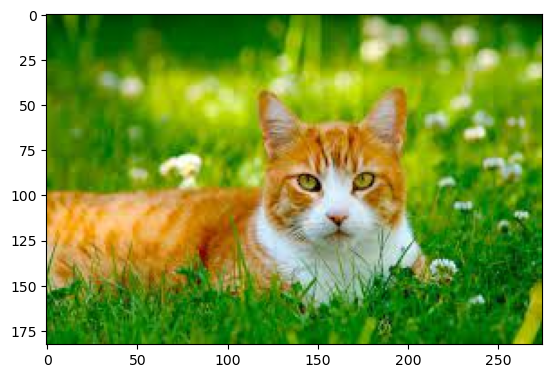

In [7]:
cat = cv2.imread('image/image_cat.JPG')
cat = cv2.cvtColor(cat, cv2.COLOR_BGR2RGB)
plt.imshow(cat);

In [8]:
cat # R과 B 자리만 바뀜

print(cat.shape) # 세로픽셀수, 가로픽셀수, 채널수(컬러는 3)
print(cat.size)  # 전체 데이터 값 개수
print(cat.dtype) # 데이터 타입
    # unint8 (unsigned interger) : 부호가 없는 정수

(183, 275, 3)
150975
uint8


### 이미지 색상 종류
- 컬러 이미지(RGB)
- 흑백 이미지(Gray) -> 0~255사이의 흑백 픽셀값으로 구성된 이미지
    - 컬러 이미지는 용량이 크고 연산량이 많기 때문에 이를 간소화 시켜 처리하기 위해서 흑백이미지를 사용함
- 이진 이미지(binary) -> 0과 255 두 가지 값으로만 구성된 이미지
    - 배경과 객체를 잘 구분
    - 관심 영역과 비관심 영역을 구분
    - 필터를 만들거나 단순한 이미지 처리를 하는 경우에 사용

### 1. 기존 컬러 이미지를 Gray로 불러오기

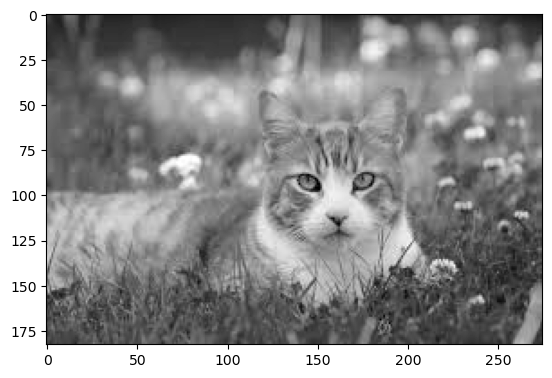

In [13]:
# 이미지를 불러올 때 gray로 받아주고, 출력할때도 gray로 설정해줘야 함
cat_gray = cv2.imread('image/image_cat.JPG', cv2.IMREAD_GRAYSCALE)
plt.imshow(cat_gray, cmap='gray');

- 2. 컬러 이미지를 그대로 불러서 cvtColor를 통해 gray로 변환 후 출력

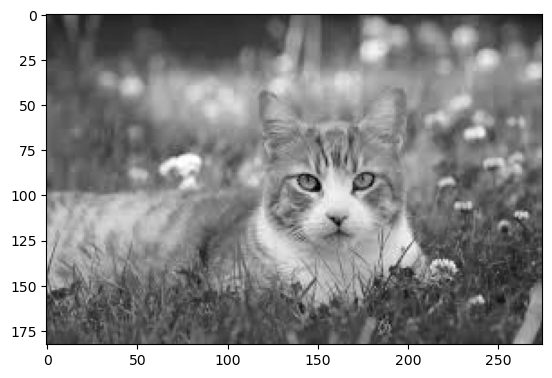

In [15]:
cat2 = cv2.imread('image/image_cat.JPG')
# 불러온 컬러 이미지를 gray로 변환하기
cat2_gray = cv2.cvtColor(cat2, cv2.COLOR_BGR2GRAY)

plt.imshow(cat2_gray, cmap='gray');

#### 이진(binary) 이미지 만들기
- 기존 이미지가 컬러 이미지라면 gray이미지로 변환 후 이진으로 바꿔줘야 함

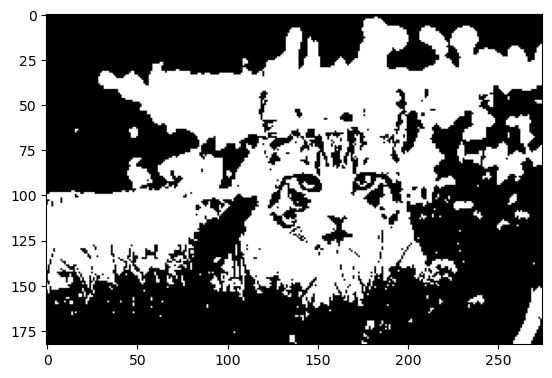

In [17]:
# threshold(문턱값, 경계값) : 특정 기준값을 통해서 데이터를 변환시켜주는 함수
# (이미지, 경계기준값, 경계값보다 클때 적용되는 값, 경계값 적용방식)
_, bi_cat = cv2.threshold(cat2_gray, 128, 255, cv2.THRESH_BINARY)

# _ : 첫번째 리턴 값을 받지 않음(threshold함수는 두 가지 값이 리턴됨)
# 리턴 값의 첫 번째는 경계값 수치, 두번째 경계값 기준이 적용된 이미지

plt.imshow(bi_cat, cmap='gray');

In [19]:
temp, bi_cat = cv2.threshold(cat2_gray, 145,255, cv2.THRESH_BINARY)
temp

145.0

In [20]:
bi_cat

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

#### cv2.threshold(img,threshold_value, value, flag)
- img : gray 이미지
- threshold_value : 경계 기준값
- value : 경계값 보다 클 때 적용되는 값
- flag : 경계값 적용 방식
    - cv2.THRESHOLD_BINARY : 픽셁밧이 경계값보다 크면 VALUE, 아니면 0을 할당(흰색 OR 검은색으로만 표시)
    - cv2.THRESH_BINARY_INV : 픽셀값이 경계값보다 크면 0, 아니면 value 할당
    - cv2.THRESH_TRUNC : 픽셀값이 경계값보다 크면 경계값, 아니면 픽셀값 할당(가장 흰 부분이 경계값으로 표시)
    - cv2.THRESH_TOZERO : 픽셀값이 경계값보다 크면 픽셀값, 아니면 0을 할당(검은색 부각)
    - cv2.THRESH_TOZERO_INV : 픽셀값이 경계값보다 크면0, 아니면 픽셀값 할당

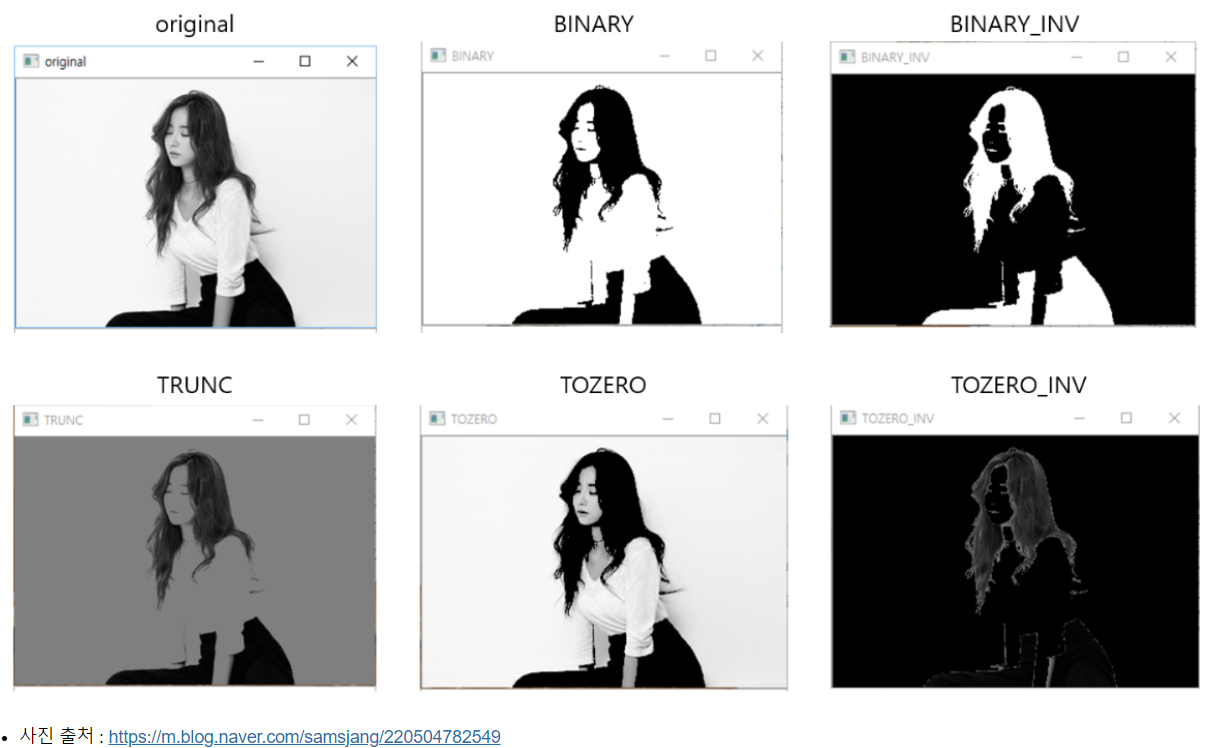

### 동영상 혹은 카메라 (웹 캠) 불러오기

비디오 캡처 성공
읽기 성공 여부: True
프레임 shape (480, 640, 3)
[[[163 156 155]
  [161 155 155]
  [156 151 153]
  ...
  [112 104 107]
  [108 104 107]
  [108 104 107]]

 [[162 153 153]
  [161 155 155]
  [156 151 153]
  ...
  [111 104 107]
  [108 105 108]
  [106 104 107]]

 [[160 153 153]
  [160 155 155]
  [157 153 154]
  ...
  [106 100 102]
  [107 104 107]
  [106 104 107]]

 ...

 [[ 66  64  56]
  [ 71  66  58]
  [ 78  70  63]
  ...
  [120 119 113]
  [116 114 110]
  [115 113 109]]

 [[ 72  65  60]
  [ 73  67  60]
  [ 75  69  61]
  ...
  [122 121 118]
  [113 113 111]
  [106 106 104]]

 [[ 72  66  58]
  [ 73  67  58]
  [ 74  68  58]
  ...
  [124 122 117]
  [120 116 112]
  [116 111 108]]]


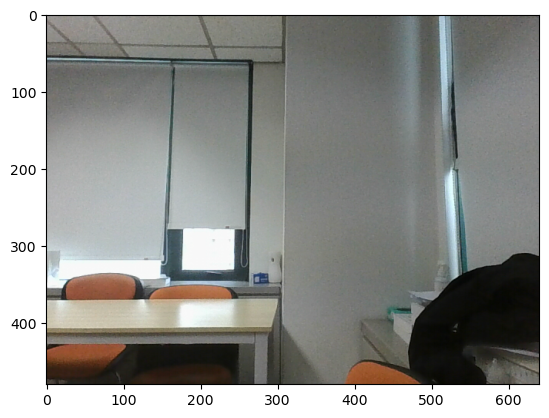

In [21]:
# 영상에 있는 프레임 출력해보기
'''영상을 다룰 때는 연속된 프레임을 실시간으로 처리해주기 때문에 제대로
   동작하지 않았을 경우에 대한 예외처리를 해주는 것이 오류로 인한 중단을
   방지하거나 오류의 위치를 파악함에 있어서 유리함'''

# 1. 영상에서 프레임을 캡쳐하기
# 코드 실행에 문제가 없을 경우
try :
    # 1) 카메라(웹캠)으로부터 캡쳐(일반적으로 내장 카메라는 0번으로 인식)
    cap = cv2.VideoCapture(0)
    print("비디오 캡처 성공")
# 코드 실행에 문제가 생길 경우
except :
    print("비디오 캡처 실패")
    
# 2. 캡쳐해온 프레임을 읽고 출력시키기
# read : 캡쳐한 이미지 프레임을 한 장씩 읽어옴
# ret : 읽기 성공여부(True, False)
# frame : 실제 이미지의 배열 데이터
ret, frame = cap.read()
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

print("읽기 성공 여부:", ret)
print("프레임 shape", frame.shape)
print(frame)
plt.imshow(frame);